Tecnica de isodata

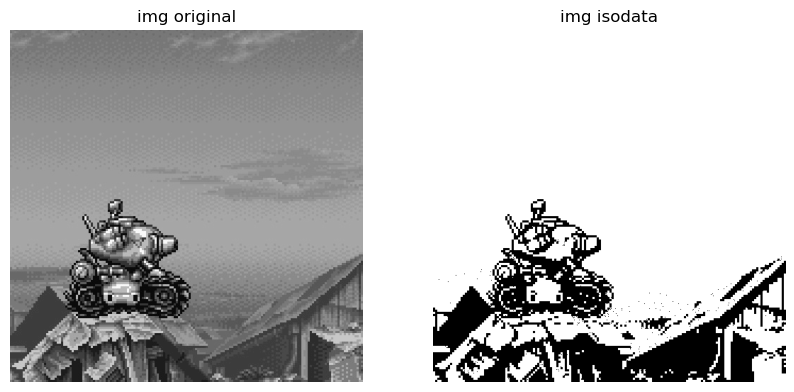

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata(imagen):
    umbral = 128
    while True:
        grupo1 = imagen[imagen<=umbral]
        grupo2 = imagen[imagen>=umbral]

        mediag1 = np.mean(grupo1)
        mediag2 = np.mean(grupo2)

        umbral_n = (mediag1+mediag2)/2

        if abs(umbral_n-umbral)<0.5:
            break

        umbral=umbral_n
    return umbral

imagen = cv2.imread('imgGIF3.jpg',0)
umbral_iso = isodata(imagen)

_,imagen_iso = cv2.threshold(imagen,umbral_iso,255,cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('img isodata')
plt.imshow(imagen_iso, cmap='gray')
plt.axis('off')

plt.show()

Tecnica de Dos picos

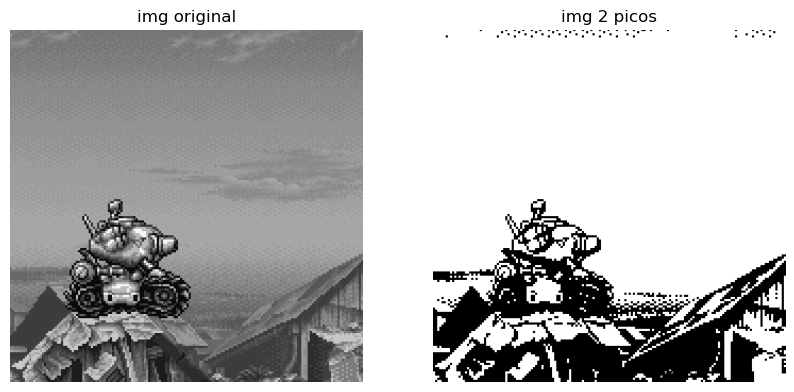

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(imagen):
    hist = cv2.calcHist([imagen],[0],None,[256],[0,256])
    pico = np.array(hist)
    pico = pico.flatten()
    pico_dif = np.diff(pico)
    primer_pico = np.argmax(pico_dif[:128])
    segundo_pico = np.argmax(pico_dif[128:])+128
    umbral_2picos = int((primer_pico+segundo_pico)/2)
    return umbral_2picos

imagen = cv2.imread('imgGIF3.jpg',0)
umbral_2pic = dos_picos(imagen)

_,imagen_2pic = cv2.threshold(imagen,umbral_2pic,255,cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('img 2 picos')
plt.imshow(imagen_2pic, cmap='gray')
plt.axis('off')

plt.show()

Tecnica de OTSU

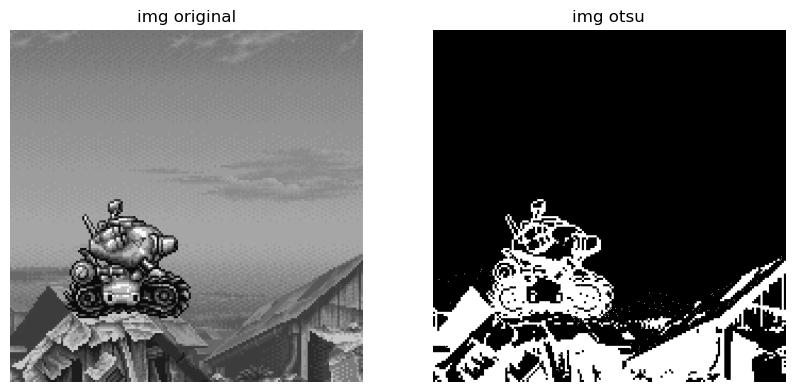

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imgGIF3.jpg',0)
_,imagen_otsu = cv2.threshold(imagen,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
umbral_otsu = np.where(imagen>imagen_otsu,255,0).astype(np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('img otsu')
plt.imshow(umbral_otsu, cmap='gray')
plt.axis('off')

plt.show()

Umbralizacion variable - Particion de una imagen

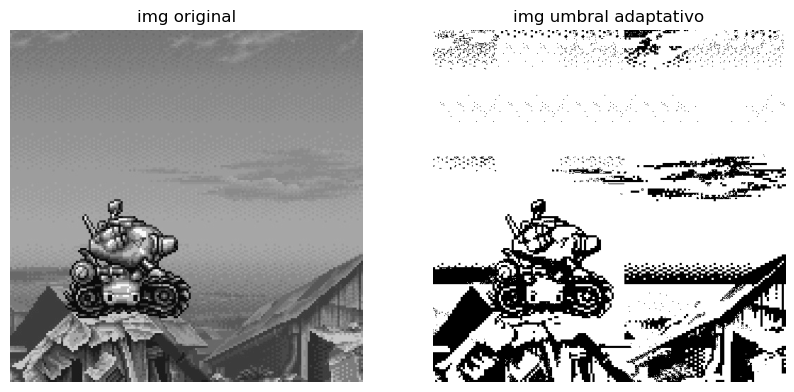

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def var_umb_blok(imagen, tam_bloq, c):
    umbral_img = np.zeros_like(imagen)
    for y in range(0,imagen.shape[0],tam_bloq):
        for x in range (0,imagen.shape[1],tam_bloq):
            bloque = imagen[y:y+tam_bloq,x:x+tam_bloq]
            bloque_media = np.mean(bloque)
            umbral_adap = bloque_media-c
            umbral_img[y:y+tam_bloq,x:x+tam_bloq]=(bloque>umbral_adap)*255
    
    return umbral_img
    
imagen = cv2.imread('imgGIF3.jpg',0)
tam_bloq = 90
c = 10
umbral_img_adap = var_umb_blok(imagen,tam_bloq,c)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('img umbral adaptativo')
plt.imshow(umbral_img_adap, cmap='gray')
plt.axis('off')

plt.show()

Con desviacion

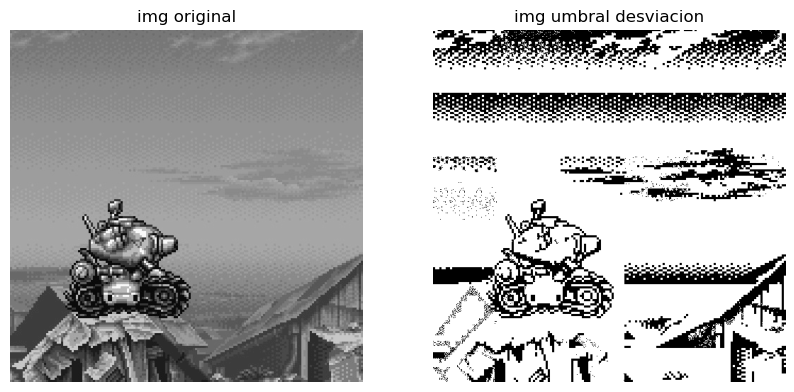

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def umbral_var2_desv(imagen,tam_bloq,ajuste):
    umbral_img = np.zeros_like(imagen)
    for y in range(0,imagen.shape[0],tam_bloq):
        for x in range (0,imagen.shape[1],tam_bloq):
            bloque = imagen[y:y+tam_bloq,x:x+tam_bloq]
            bloque_media = np.mean(bloque)

            desv = np.std(bloque)

            umbral_adap = bloque_media-(ajuste*desv)
            umbral_img[y:y+tam_bloq,x:x+tam_bloq]=(bloque>umbral_adap)*255
            
    return umbral_img
    
imagen = cv2.imread('imgGIF3.jpg',0)
tam_bloq = 90
a = 0.8
umbral_img_adap2 = umbral_var2_desv(imagen,tam_bloq,a)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('img umbral desviacion')
plt.imshow(umbral_img_adap2, cmap='gray')
plt.axis('off')

plt.show()

Adaptativo con ventana

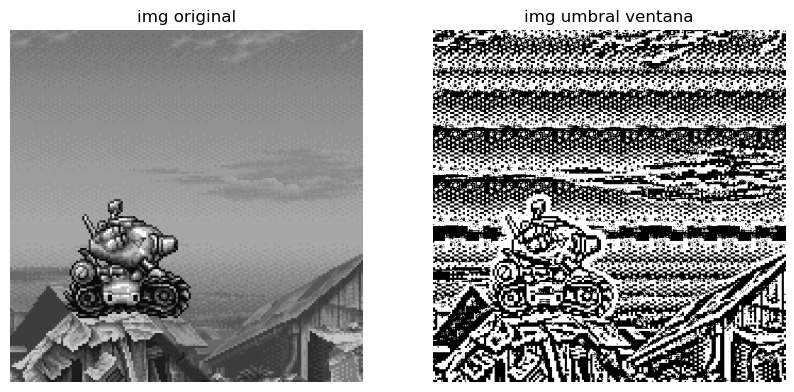

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def vantana(imagen, ventana, factor):
    umbral_imgV = np.zeros_like(imagen)
    pad = ventana//2
    pad_img=cv2.copyMakeBorder(imagen,pad,pad,pad,pad,cv2.BORDER_REPLICATE) 
    for y in range(imagen.shape[0]):
        for x in range (imagen.shape[1]):
            ventana1 = pad_img[y:y+ventana,x:x+ventana]
            media = np.mean(ventana1)
            dist = np.std(ventana)
            umbral = media - (factor*dist)
            umbral_imgV[y,x]=255 if imagen[y,x]>umbral else 0

    return umbral_imgV


imagen = cv2.imread('imgGIF3.jpg',0)
tam_bloq = 15
f = 2
umbral_img_V = vantana(imagen,tam_bloq,f)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('img umbral ventana')
plt.imshow(umbral_img_V, cmap='gray')
plt.axis('off')

plt.show()

Funcion de CV2

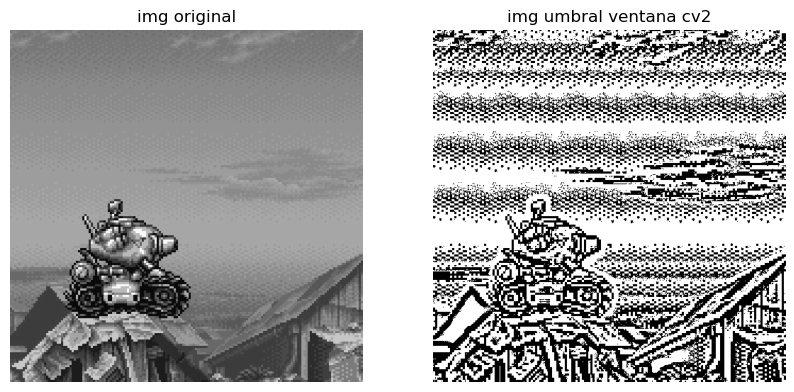

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imgGIF3.jpg',0)
ventana = 15
f = 2
imagen_umbral = cv2.adaptiveThreshold(imagen,255,cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, ventana, f)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('img umbral ventana cv2')
plt.imshow(imagen_umbral, cmap='gray')
plt.axis('off')

plt.show()
